# Random Forest Regression – Meat Price Prediction

**Target Variable:** `price_eur_per_kg` (continuous)

**What is a Random Forest?**
A Random Forest trains many Decision Trees (e.g. 200) on random subsets of
the training data. Each tree sees different rows and different features.
The final prediction is the **average** of all tree predictions.

**Why this helps:**
- A single tree makes one hard boundary → if it's wrong, no recovery
- A forest averages 200 opinions → individual errors cancel out
- Result: more robust predictions, especially on noisy or unseen data

**Workflow:**
1. Load & explore the dataset
2. Define features and target, train/test split
3. Train a Random Forest Regressor (baseline, no tuning)
4. Evaluate on the internal test set
5. Compare feature importance with Decision Tree
6. Stress-test with the edge-case dataset
7. Side-by-side comparison with Decision Tree results


## Step 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load the Training Dataset


In [3]:
df = pd.read_csv("meat_price_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Missing values:{df.isnull().sum()}")
df.head()


Shape: (1200, 9)
Missing values:meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
dtype: int64


,meat_type,fat_content_pct,protein_pct,marbling_score,animal_age_months,storage_days,organic,cut_quality,price_eur_per_kg
0,1,17.8,21.7,7,49,14,1,3,17.27
1,4,27.1,21.9,9,22,4,0,4,29.69
2,4,31.8,16.5,7,20,1,0,2,24.41
3,3,25.8,22.6,6,11,16,0,2,15.08
4,3,33.8,22.4,5,2,17,0,4,20.57


## Step 3 – Define Features and Target


In [4]:
target_col = "price_eur_per_kg"

feature_cols = [c for c in df.columns if c != target_col]
print("Features:", feature_cols)

X = df[feature_cols]
y = df[target_col]

print(f"X shape: {X.shape}  |  y shape: {y.shape}")


Features: ['meat_type', 'fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality']
X shape: (1200, 8)  |  y shape: (1200,)


## Step 4 – Train / Test Split (80/20)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test  set: {X_test.shape[0]} rows")


Train set: 960 rows
Test  set: 240 rows


## Step 5 – Train the Random Forest Regressor

**Key parameters (baseline — no tuning yet):**
- `n_estimators=200` — 200 trees in the forest
- `max_depth=7` — same depth as our best Decision Tree for fair comparison
- `random_state=42` — reproducibility
- `n_jobs=-1` — use all CPU cores for faster training


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
)

# n_jobs=-1 = use all CPU cores to train the 200 trees in parallel instead of one by one → faster training, same results.

rf_model.fit(X_train, y_train)

print("Model trained.")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth:       {rf_model.max_depth}")


Model trained.
Number of trees: 200
Max depth:       7


## Step 6 – Evaluate on the Internal Test Set


In [7]:
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} EUR")
print(f"RMSE : {rmse:.2f} EUR")
print(f"R²   : {r2:.4f}")
print(f"Mean price: {y_test.mean():.2f} EUR")
print(f"Relative error (MAE / mean): {mae / y_test.mean() * 100:.1f}%")


MAE  : 1.80 EUR
RMSE : 2.25 EUR
R²   : 0.9249
Mean price: 23.41 EUR
Relative error (MAE / mean): 7.7%


## Step 7 – Actual vs Predicted Plot


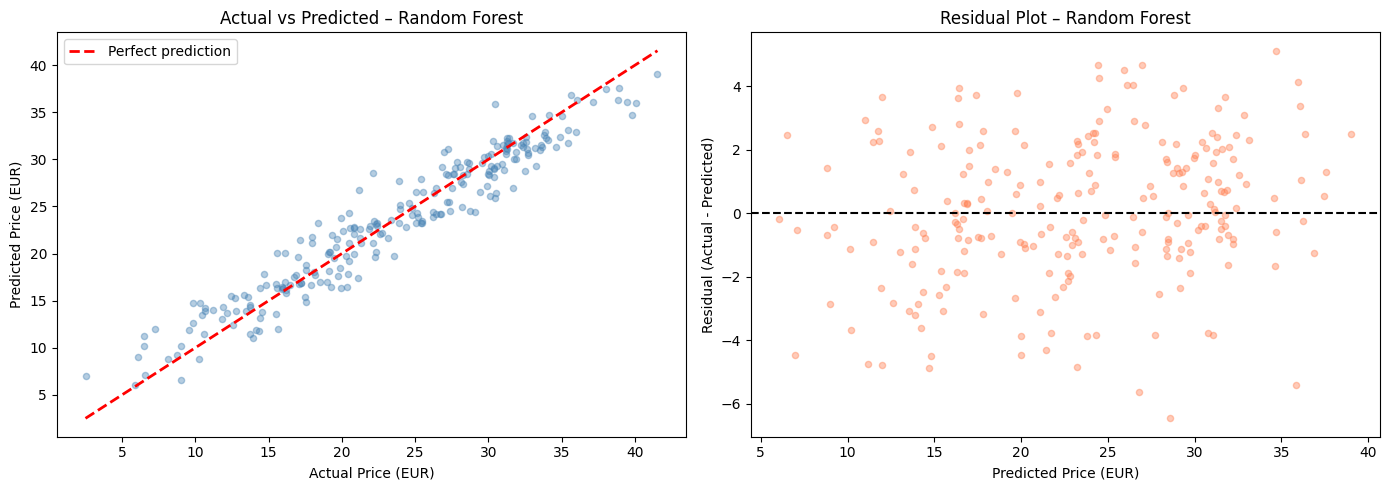

Mean residual: 0.08
Std  residual: 2.25


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted – Random Forest")
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=20, color="coral")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot – Random Forest")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std  residual: {residuals.std():.2f}")


## Step 8 – Feature Importance

Random Forest calculates importance by averaging across all 200 trees.
This is more stable than a single tree's importance.


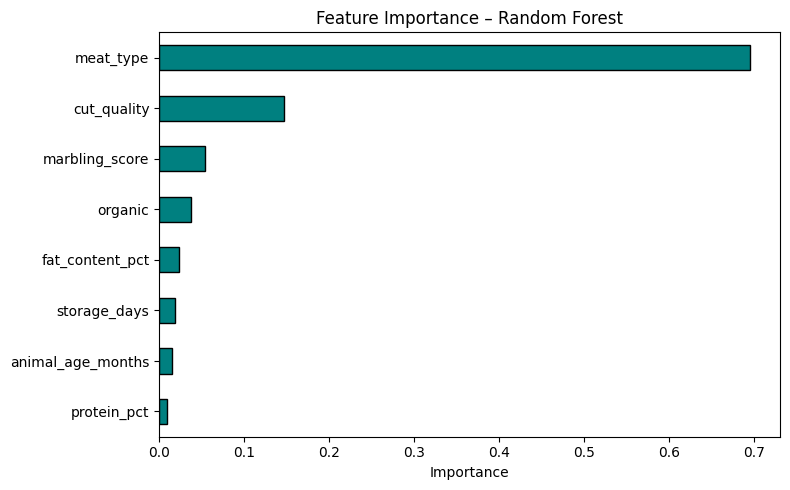

Importance values:
protein_pct          0.0091
animal_age_months    0.0150
storage_days         0.0189
fat_content_pct      0.0228
organic              0.0379
marbling_score       0.0542
cut_quality          0.1468
meat_type            0.6952
dtype: float64


In [10]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))


## Step 9 – Load and Preprocess the Stress-Test Dataset


In [12]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print(f"Shape: {df_stress.shape}")
print(f"Missing values:{df_stress.isnull().sum()}")

# Separate features & target
X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# Impute with training medians
train_medians = X_train.median()
X_stress_filled = X_stress.fillna(train_medians)

# Drop rows where target is NaN
valid_mask = y_stress.notna()
X_stress_valid = X_stress_filled[valid_mask]
y_stress_valid = y_stress[valid_mask]

print(f"Usable stress-test rows: {X_stress_valid.shape[0]} / {len(df_stress)}")


Shape: (100, 9)
Missing values:meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64
Usable stress-test rows: 91 / 100


## Step 10 – Evaluate on the Stress-Test Data


In [13]:
y_stress_pred = rf_model.predict(X_stress_valid)

mae_s  = mean_absolute_error(y_stress_valid, y_stress_pred)
rmse_s = np.sqrt(mean_squared_error(y_stress_valid, y_stress_pred))
r2_s   = r2_score(y_stress_valid, y_stress_pred)

print(f"Stress-Test MAE  : {mae_s:.2f} EUR")
print(f"Stress-Test RMSE : {rmse_s:.2f} EUR")
print(f"Stress-Test R²   : {r2_s:.4f}")
print(f"Mean price: {y_stress_valid.mean():.2f} EUR")
print(f"Relative error (MAE / mean): {mae_s / y_stress_valid.mean() * 100:.1f}%")


Stress-Test MAE  : 8.68 EUR
Stress-Test RMSE : 11.33 EUR
Stress-Test R²   : -0.3288
Mean price: 29.97 EUR
Relative error (MAE / mean): 29.0%


## Step 11 – Stress-Test Visualisation


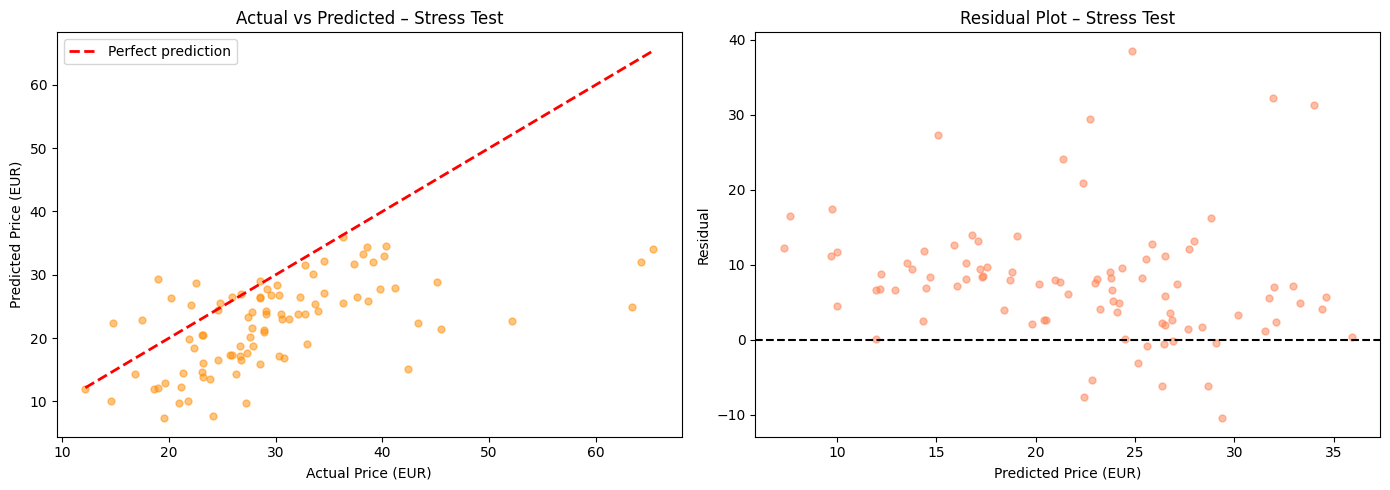

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_stress_valid, y_stress_pred, alpha=0.5, s=25, color="darkorange")
axes[0].plot(
    [y_stress_valid.min(), y_stress_valid.max()],
    [y_stress_valid.min(), y_stress_valid.max()],
    color="red", linestyle="--", linewidth=2, label="Perfect prediction",
)
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted – Stress Test")
axes[0].legend()

residuals_s = y_stress_valid - y_stress_pred
axes[1].scatter(y_stress_pred, residuals_s, alpha=0.5, s=25, color="coral")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot – Stress Test")

plt.tight_layout()
plt.show()


## Step 12 – Side-by-Side Comparison: Decision Tree vs Random Forest

Paste your Decision Tree results here for comparison.


In [19]:
# --- Decision Tree results (from previous notebook) ---
dt_results = {
    "MAE_test":  2.38, "RMSE_test":  2.92, "R2_test":  0.8737,
    "MAE_stress": 8.59, "RMSE_stress": 11.00, "R2_stress": -0.2544,
}

comparison = pd.DataFrame({
    "Metric":         ["MAE (EUR)", "RMSE (EUR)", "R²"],
    "DT Test":        [f"{dt_results['MAE_test']:.2f}", f"{dt_results['RMSE_test']:.2f}", f"{dt_results['R2_test']:.4f}"],
    "RF Test":        [f"{mae:.2f}", f"{rmse:.2f}", f"{r2:.4f}"],
    "DT Stress":      [f"{dt_results['MAE_stress']:.2f}", f"{dt_results['RMSE_stress']:.2f}", f"{dt_results['R2_stress']:.4f}"],
    "RF Stress":      [f"{mae_s:.2f}", f"{rmse_s:.2f}", f"{r2_s:.4f}"],
})

print(comparison.to_string(index=False))
print("
--- Done! ---")


SyntaxError: unterminated string literal (detected at line 16) (556404079.py, line 16)